In [1]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from driver_genes.viutils import valid_filename, get_palette, adjust_color

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
sns.set_theme(style="ticks")


In [8]:
our_dir = '../results'


job_dict = {
    ('Kowalski', 'HEK293FT', 'K562'): {
        'Ours': {
            'true': f'{our_dir}/kowalski/hek293ft_noisy-seed42/test_epoch_metrics_true.csv',
            'noisy': f'{our_dir}/kowalski/hek293ft_noisy-seed42/test_epoch_metrics.csv'
        },
    },
    ('Kowalski', 'K562', 'HEK293FT'): {
        'Ours': {
            'true': f'{our_dir}/kowalski/k562_noisy-seed42/test_epoch_metrics_true.csv',
            'noisy': f'{our_dir}/kowalski/k562_noisy-seed42/test_epoch_metrics.csv'
        },
    },
}

metrics_list = []
for (dataset, train_on, test_on), method_dict in job_dict.items():
    for method, label_dict in method_dict.items():
        for label, path_dict in label_dict.items():
            print('-'*100)
            print(f'{dataset}, {train_on}, {test_on}, {method}, {label}, {path_dict}')
            if not os.path.exists(path_dict):
                print(f'{path_dict} does not exist')
                continue
            metrics_df = pd.read_csv(path_dict)
            # print(metrics_df.head(5))
            metrics_list.append(metrics_df.assign(
                Dataset=dataset,
                Train=train_on,
                Test=metrics_df['prefix'].map(
                    lambda x: train_on if train_on in x else test_on if test_on in x else None
                ),
                Method=method,
                Label=label,
                Group=metrics_df['prefix'].map(
                    lambda x: 'ID' if train_on in x else 'OOD' if test_on in x else 'All'
                )
            ).query('Group != "All"').reset_index(drop=True))
                
our_metrics_df = pd.concat(metrics_list)

----------------------------------------------------------------------------------------------------
Kowalski, HEK293FT, K562, Ours, true, ../results/kowalski/hek293ft_noisy-seed42/test_epoch_metrics_true.csv
----------------------------------------------------------------------------------------------------
Kowalski, HEK293FT, K562, Ours, noisy, ../results/kowalski/hek293ft_noisy-seed42/test_epoch_metrics.csv
----------------------------------------------------------------------------------------------------
Kowalski, K562, HEK293FT, Ours, true, ../results/kowalski/k562_noisy-seed42/test_epoch_metrics_true.csv
----------------------------------------------------------------------------------------------------
Kowalski, K562, HEK293FT, Ours, noisy, ../results/kowalski/k562_noisy-seed42/test_epoch_metrics.csv


In [9]:
other_metrics_df = pd.read_parquet('data/noisy_metrics.parquet').query('Method != "Ours" and Dataset != "Simulation"')
metrics_df = pd.concat([our_metrics_df, other_metrics_df], join='inner').dropna(axis=1)
metrics_df.rename(columns=lambda x: x.replace('sample#', ''), inplace=True)

In [13]:
col_order = [
    ('Kowalski', 'HEK293FT'),
    # ('Kowalski', 'K562'),
]
order = [
    'Ours', 'CellNavi', 
    'GEARS', 'CPA', 'DEG'
]
metric_keys = [
    'RelPos', 'ACC@Top1', 'Recall@Top5',
    'label#AUROC', 'label#AUPRC', 'label#F1'  
]
id_vars = ['Dataset', 'Train', 'Test', 'Method', 'Label', 'Group']
colors_sel = get_palette().colors
colors_sel_light = [adjust_color(c, l_factor=1.2, return_type='hex') for c in colors_sel]
# Grouped bars (x=Method, hue=Label): one hue level uses main colors per method index, the other uses light.
# Adjust keys if your Label strings differ from the parquet.
hue_order = ['noisy', 'true']
label_palette = {'noisy': colors_sel_light, 'true': colors_sel}
print(colors_sel, colors_sel_light)

['#A67EB7', '#6F94CD', '#5DA39D', '#EF845D', '#9AA7B1'] ['#c1a6cd', '#9eb7dd', '#7eb6b1', '#f5b299', '#bfc8ce']


In [14]:
['#A67EB7', '#6F94CD', '#5DA39D', '#EF845D', '#9AA7B1']
['#c1a6cd', '#9eb7dd', '#7eb6b1', '#f5b299', '#bfc8ce']

['#c1a6cd', '#9eb7dd', '#7eb6b1', '#f5b299', '#bfc8ce']

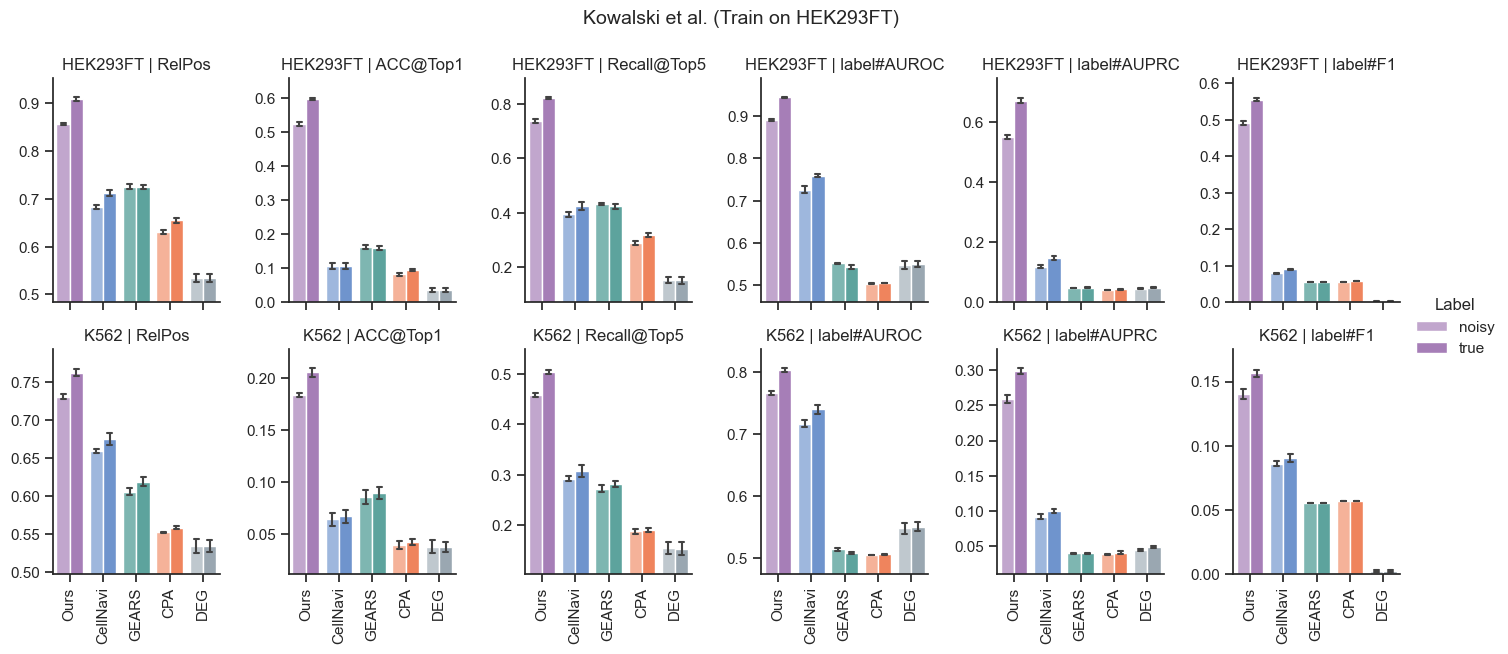

In [15]:
for dataset, train_on in col_order:
    plot_df = (
        metrics_df
        .query('(Dataset == @dataset) and (Train == @train_on)')
        .groupby(id_vars)
        [metric_keys + id_vars]
        .sample(n=5)
        # .reset_index(drop=False)
        .melt(id_vars=id_vars, var_name='Metric', value_name='Value')
    )
    hue_order_eff = [h for h in hue_order if h in plot_df['Label'].unique()]
    g = sns.catplot(
        kind='bar',
        data=plot_df,
        x='Method',
        order=order,
        y='Value',
        row='Test',
        col='Metric',
        errorbar='sd',
        capsize=0.3,
        err_kws={'linewidth': 1.5},
        hue='Label',
        hue_order=hue_order_eff,
        palette=['#d0d0d0'] * len(hue_order_eff),
        sharey=False,
        height=3,
        aspect=0.8,
    )
    g.set_titles('{row_name} | {col_name}')
    g.set_xlabels("")
    g.set_ylabels("")
    g.tick_params(axis="x", labelrotation=90)
    for ax in g.axes.flat:
        for hi, container in enumerate(ax.containers):
            if hi >= len(hue_order_eff):
                break
            lab = hue_order_eff[hi]
            pal = label_palette.get(lab)
            if pal is None:
                continue
            for mi, patch in enumerate(container.patches):
                if mi < len(pal):
                    patch.set_facecolor(pal[mi])
    leg = getattr(g, '_legend', None)
    if leg is not None:
        for h, lab in zip(leg.legend_handles, hue_order_eff):
            pal = label_palette.get(lab)
            if pal is not None:
                h.set_facecolor(pal[0])
    for j, metric in enumerate(g.col_names):          # col='Metric'
        for i, test_on in enumerate(g.row_names):     # row='Test on'
            ax = g.axes[i, j]

            s = plot_df.loc[
                (plot_df["Metric"] == metric) & (plot_df["Test"] == test_on),
                "Value"
            ].dropna()

            lo, hi = s.min(), s.max()
            pad = 0.1 * (hi - lo) if hi > lo else (abs(hi) * 0.1 + 1e-6)
            ax.set_ylim(max(0, lo - pad), hi + pad)
    g.figure.suptitle(dataset + ' et al. (Train on ' + train_on + ')', fontsize=14, y=1.05)
    g.figure.show()
    g.figure.savefig(f'../figures/5_benchmark_noisy_prediction_{dataset}_{train_on}.pdf')
        

In [16]:
id_vars_nolabel = list(set(id_vars) - {'Label'})
delta_metrics_df = (
    metrics_df.query('Label == "true"')
    .set_index(id_vars_nolabel)
    .drop(columns=['Label'])
    .sub(
        metrics_df.query('Label == "noisy"')
        .set_index(id_vars_nolabel)
        .drop(columns=['Label'])
    )
    .rename(columns=lambda x: '$\\Delta$' + x)
    .reset_index(drop=False)
)

delta_metrics_df.head(5)


,Group,Dataset,Train,Test,Method,$\Delta$ACC@Top1,$\Delta$ACC@Top5,$\Delta$Coverage,$\Delta$MRR,$\Delta$RankingLoss,...,$\Delta$label#Recall,$\Delta$nDCG,$\Delta$AUPRC,$\Delta$AUROC,$\Delta$F1@Top1,$\Delta$F1@Top5,$\Delta$Precision@Top1,$\Delta$Precision@Top5,$\Delta$Recall@Top1,$\Delta$Recall@Top5
0,ID,Kowalski,HEK293FT,HEK293FT,Ours,0.061554,0.080148,-1.364048,0.063473,-0.041335,...,0.066684,0.051897,0.063473,0.041335,0.061554,0.026716,0.061554,0.016030,0.061554,0.080148
1,ID,Kowalski,HEK293FT,HEK293FT,Ours,0.055564,0.077250,-1.773709,0.063592,-0.053749,...,0.056359,0.052844,0.063592,0.053749,0.055564,0.025750,0.055564,0.015450,0.055564,0.077250
2,OOD,Kowalski,HEK293FT,K562,Ours,0.022729,0.047145,-1.256292,0.032724,-0.038069,...,0.015094,0.028213,0.032724,0.038070,0.022729,0.015715,0.022729,0.009429,0.022729,0.047145
3,ID,Kowalski,HEK293FT,HEK293FT,Ours,0.069746,0.085991,-1.474395,0.071686,-0.044679,...,0.058578,0.058431,0.071686,0.044679,0.069746,0.028663,0.069746,0.017198,0.069746,0.085990
4,ID,Kowalski,HEK293FT,HEK293FT,Ours,0.064967,0.084173,-1.799713,0.072192,-0.054537,...,0.061106,0.059500,0.072192,0.054537,0.064967,0.028058,0.064967,0.016835,0.064967,0.084173


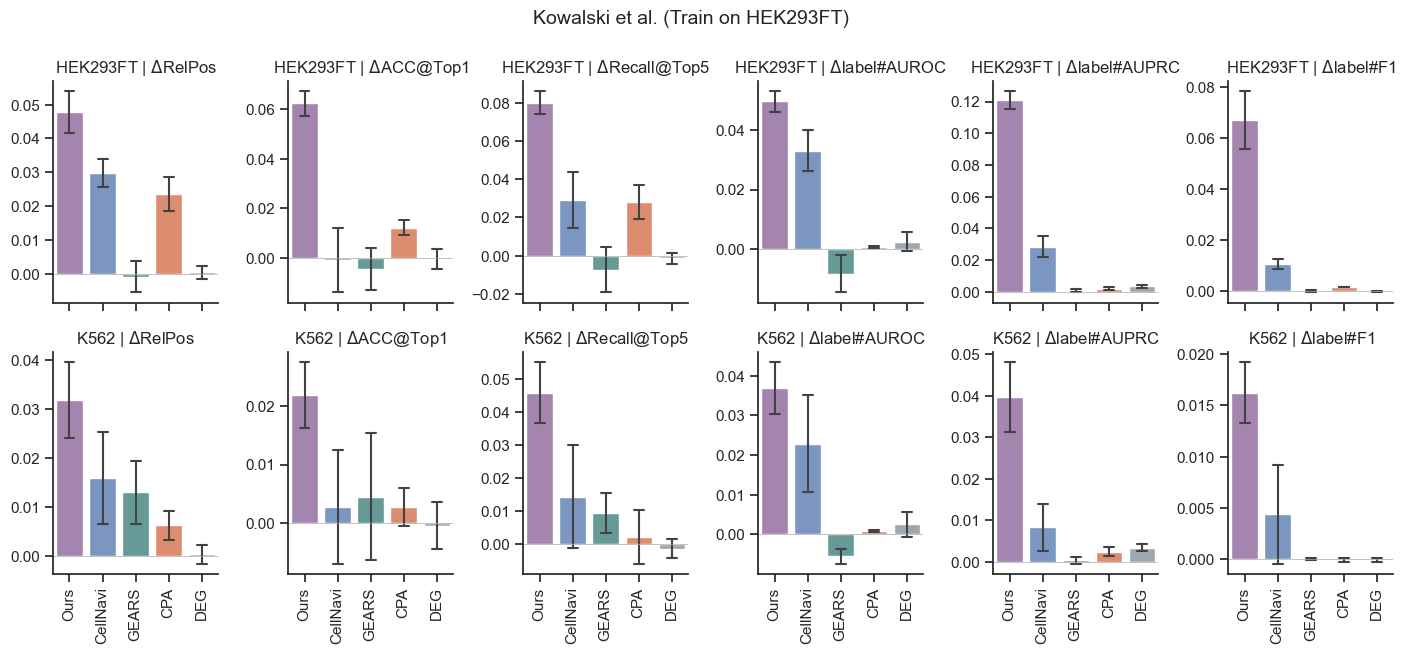

In [17]:
for dataset, train_on in col_order:
    plot_df = (
        delta_metrics_df
        .query('(Dataset == @dataset) and (Train == @train_on)')
        .groupby(id_vars_nolabel)
        [['$\\Delta$' + m for m in metric_keys] + id_vars_nolabel]
        .sample(n=5)
        # .reset_index(drop=False)
        .melt(id_vars=id_vars_nolabel, var_name='Metric', value_name='Value')
    )
    g = sns.catplot(
        kind='bar',
        data=plot_df,
        x='Method',
        order=order,
        y='Value',
        row='Test',
        col='Metric',
        errorbar='sd',
        capsize=0.3,
        err_kws={'linewidth': 1.5},
        hue='Method',
        hue_order=order,
        palette=colors_sel,
        sharey=False,
        height=3,
        aspect=0.8,
    )
    g.set_titles('{row_name} | {col_name}')
    g.set_xlabels("")
    g.set_ylabels("")
    g.tick_params(axis="x", labelrotation=90)
    for j, metric in enumerate(g.col_names):          # col='Metric'
        for i, test_on in enumerate(g.row_names):     # row='Test on'
            ax = g.axes[i, j]
            ax.axhline(0, color='#aaaaaa', linewidth=0.5) # add a horizontal line at y=0
    g.figure.suptitle(dataset + ' et al. (Train on ' + train_on + ')', fontsize=14, y=1.05)
    g.figure.savefig(f'../figures/5_benchmark_noisy_prediction_delta_{dataset}_{train_on}.pdf')
    g.figure.show()
